# Proyecto Fin de Curso: Predicción de la Demanda Energética en España (2015-2018)

## HITO 1

**Estudiante:** Marta Requejo Merino 

**Especialidad:** Grado en IA y Big Data 

---

In [23]:
# System and Environment
import os
from dotenv import load_dotenv

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# AWS Cloud
import awswrangler as wr
import boto3

# Preprocessing (lo único de sklearn necesario para limpiar y escalar)
from sklearn.preprocessing import StandardScaler

# Persistence
import joblib

In [ ]:


# 1. Definir rutas
BASE_DIR = os.path.dirname(os.getcwd()) 
DATA_DIR = os.path.join(BASE_DIR, 'datos')
PROCESSED_DIR = os.path.join(BASE_DIR, 'datos_procesados')
MODELS_DIR = os.path.join(BASE_DIR, 'modelos')
# Asegurar que existan las carpetas por si acaso
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Ruta base configurada: {BASE_DIR}")

Ruta base configurada: c:\Users\marti\Desktop\proyecto energia


## 4. Análisis Exploratorio de Datos (EDA)

En esta fase vamos a entender la naturaleza de nuestros datos de consumo energético y clima (2015-2019), identificar patrones, detectar valores atípicos y evaluar las relaciones entre las variables para tomar decisiones fundamentadas durante la limpieza.

#### Carga de datos

In [25]:
BASE_DIR = os.path.dirname(os.getcwd())
RUTA_ENV = os.path.join(BASE_DIR, '.env')
BUCKET_NAME = os.getenv("S3_BUCKET_NAME", "energia-espana")

# Configuración del entorno y carga de credenciales
pd.set_option('display.max_columns', None)

# Ruta y carga del archivo de secretos .env
load_dotenv(dotenv_path=RUTA_ENV, override=True)

#Configurar la sesión de AWS
boto3.setup_default_session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    aws_session_token=os.getenv("AWS_SESSION_TOKEN"),
    region_name=os.getenv("AWS_REGION", "us-east-1")
)

# Importación del Dataset desde S3
ruta_s3 = f"s3://{BUCKET_NAME}/processed/dataset_unificado/"

print(f"Descargando datos desde: {ruta_s3}")
df = wr.s3.read_parquet(path=ruta_s3)

# Ordenar cronológicamente y resetear índice
df = df.sort_values('time').reset_index(drop=True)

print(f"Carga completada. El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

Descargando datos desde: s3://energia-espana/processed/dataset_unificado/
Carga completada. El dataset contiene 35064 filas y 37 columnas.



#### Preparación previa temporal

In [26]:

# 1. Convertimos a datetime respetando el timezone original (UTC)
df['time'] = pd.to_datetime(df['time'], utc=True)

# 2. Convertimos a hora local (Europe/Madrid) para evitar el desfase horario
df['time_local'] = df['time'].dt.tz_convert('Europe/Madrid')

# 3. Extraemos solo lo que falta usando la hora local correcta
df['hour'] = df['time_local'].dt.hour
df['day_of_week'] = df['time_local'].dt.dayofweek # 0=Monday, 6=Sunday

# Comprobación de datos
display(df[['time', 'time_local', 'year', 'month', 'day', 'hour', 'day_of_week']].head())

# primeros 5 registros
display(df.head())

,time,time_local,year,month,day,hour,day_of_week
0,2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,2015,01,01,0,3
1,2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,2015,01,01,1,3
2,2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,2015,01,01,2,3
3,2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,2015,01,01,3,3
4,2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,2015,01,01,4,3


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,year,month,day,temp_madrid,temp_barcelona,temp_valencia,temp_seville,temp_bilbao,time_local,hour,day_of_week
0,2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17.0,,6436.0,26118.0,25385.0,50.10,65.41,2015,01,01,267.325,281.625,270.475,273.375,269.657312,2015-01-01 00:00:00+01:00,0,3
1,2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16.0,,5856.0,24934.0,24382.0,48.10,64.92,2015,01,01,267.325,281.625,270.475,273.375,269.763500,2015-01-01 01:00:00+01:00,1,3
2,2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8.0,,5454.0,23515.0,22734.0,47.33,64.48,2015,01,01,266.186,281.286,269.686,274.086,269.251688,2015-01-01 02:00:00+01:00,2,3
3,2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2.0,,5151.0,22642.0,21286.0,42.27,59.32,2015,01,01,266.186,281.286,269.686,274.086,269.203344,2015-01-01 03:00:00+01:00,3,3
4,2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9.0,,4861.0,21785.0,20264.0,38.41,56.04,2015,01,01,266.186,281.286,269.686,274.086,269.485500,2015-01-01 04:00:00+01:00,4,3


### 4.1. Inspección Inicial
Comenzamos estandarizando los nombres de las columnas (sustituyendo espacios por guiones bajos para facilitar la programación) y analizando los tipos de datos que componen nuestro dataset unificado.

In [27]:
# Estandarizar nombres de columnas
df.columns = df.columns.str.replace(' ', '_')

display(df.head())

,time,generation_biomass,generation_fossil_brown_coal/lignite,generation_fossil_coal-derived_gas,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_fossil_oil_shale,generation_fossil_peat,generation_geothermal,generation_hydro_pumped_storage_aggregated,generation_hydro_pumped_storage_consumption,generation_hydro_run-of-river_and_poundage,generation_hydro_water_reservoir,generation_marine,generation_nuclear,generation_other,generation_other_renewable,generation_solar,generation_waste,generation_wind_offshore,generation_wind_onshore,forecast_solar_day_ahead,forecast_wind_offshore_eday_ahead,forecast_wind_onshore_day_ahead,total_load_forecast,total_load_actual,price_day_ahead,price_actual,year,month,day,temp_madrid,temp_barcelona,temp_valencia,temp_seville,temp_bilbao,time_local,hour,day_of_week
0,2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17.0,,6436.0,26118.0,25385.0,50.10,65.41,2015,01,01,267.325,281.625,270.475,273.375,269.657312,2015-01-01 00:00:00+01:00,0,3
1,2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16.0,,5856.0,24934.0,24382.0,48.10,64.92,2015,01,01,267.325,281.625,270.475,273.375,269.763500,2015-01-01 01:00:00+01:00,1,3
2,2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8.0,,5454.0,23515.0,22734.0,47.33,64.48,2015,01,01,266.186,281.286,269.686,274.086,269.251688,2015-01-01 02:00:00+01:00,2,3
3,2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2.0,,5151.0,22642.0,21286.0,42.27,59.32,2015,01,01,266.186,281.286,269.686,274.086,269.203344,2015-01-01 03:00:00+01:00,3,3
4,2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9.0,,4861.0,21785.0,20264.0,38.41,56.04,2015,01,01,266.186,281.286,269.686,274.086,269.485500,2015-01-01 04:00:00+01:00,4,3


In [28]:
print("\n--- TIPOS DE DATOS Y NULOS INICIALES ---")
df.info()


--- TIPOS DE DATOS Y NULOS INICIALES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 40 columns):
 #   Column                                       Non-Null Count  Dtype                        
---  ------                                       --------------  -----                        
 0   time                                         35064 non-null  datetime64[ns, UTC]          
 1   generation_biomass                           35045 non-null  float64                      
 2   generation_fossil_brown_coal/lignite         35046 non-null  float64                      
 3   generation_fossil_coal-derived_gas           35046 non-null  float64                      
 4   generation_fossil_gas                        35046 non-null  float64                      
 5   generation_fossil_hard_coal                  35046 non-null  float64                      
 6   generation_fossil_oil                        35045 non-null  float64        

### 4.2. Estadísticas Descriptivas
Analizamos las métricas de centralización y dispersión de las variables numéricas. Esto nos ayuda a entender la escala de la demanda eléctrica y de las variables meteorológicas, así como a detectar valores físicos imposibles de un vistazo rápido.

In [29]:
# Estadísticas descriptivas (transpuestas para mejor lectura)
display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
generation_biomass,35045.0,383.51,85.35,0.00,333.00,367.00,433.00,592.00
generation_fossil_brown_coal/lignite,35046.0,448.06,354.57,0.00,0.00,509.00,757.00,999.00
generation_fossil_coal-derived_gas,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation_fossil_gas,35046.0,5622.74,2201.83,0.00,4126.00,4969.00,6429.00,20034.00
generation_fossil_hard_coal,35046.0,4256.07,1961.60,0.00,2527.00,4474.00,5838.75,8359.00
generation_fossil_oil,35045.0,298.32,52.52,0.00,263.00,300.00,330.00,449.00
generation_fossil_oil_shale,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation_fossil_peat,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation_geothermal,35046.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
generation_hydro_pumped_storage_consumption,35045.0,475.58,792.41,0.00,0.00,68.00,616.00,4523.00


Como nota vemos que hay variables que vienen a 0 como `generation_wind_offshore`o `generation_fossil_oil_shale`, las tendremos en cuenta cuando analicemos en profundidad los datos

### 4.3. Análisis Univariante

#### 4.3.1


Un histograma que cuenta cuántas horas a lo largo de estos años el consumo eléctrico se situó en un rango de Megavatios determinado. La línea superpuesta muestra la tendencia de la distribución.


Nos permite confirmar si la demanda nacional sigue una distribución normal o si está sesgada. Además, nos ayuda a identificar visualmente los valles de consumo (horas de menor demanda) y los picos máximos a los que se enfrenta la red eléctrica española.

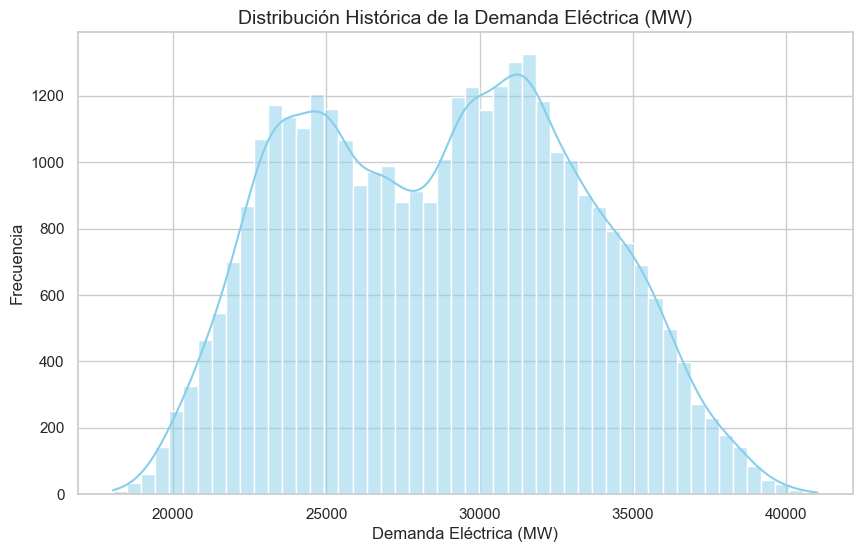

In [30]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['total_load_actual'], bins=50, kde=True, color='skyblue')
plt.title('Distribución Histórica de la Demanda Eléctrica (MW)', fontsize=14)
plt.xlabel('Demanda Eléctrica (MW)')
plt.ylabel('Frecuencia')
plt.show()

#### 4.3.2 Relación entre Clima y Demanda

Este es un mapa de puntos donde cada punto representa una hora del histórico. El eje X mide la temperatura en Madrid y el eje Y mide la demanda total de España en esa misma hora.

Esta gráfica ilustra un fenómeno clave en la ingeniería energética: la dependencia térmica no lineal. Como se puede apreciar, la nube de puntos forma una especie de "U". La demanda sube drásticamente en los extremos izquierdo (bajas temperaturas invernales que activan calefacciones) y derecho (altas temperaturas estivales que activan aires acondicionados), mientras que en el centro (temperaturas suaves de primavera/otoño) el consumo se relaja. Esta no linealidad nos indica que usar solo modelos lineales simples podría no ser suficiente para captar la complejidad climática.

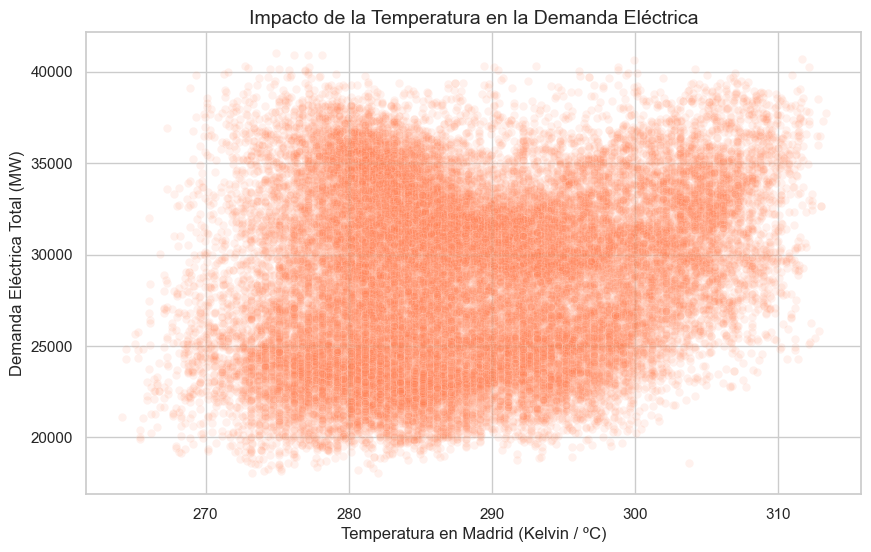

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temp_madrid', y='total_load_actual', alpha=0.1, color='coral')
plt.title('Impacto de la Temperatura en la Demanda Eléctrica', fontsize=14)
plt.xlabel('Temperatura en Madrid (Kelvin / ºC)')
plt.ylabel('Demanda Eléctrica Total (MW)')
plt.show()

**Conclusiones de la Relación Clima-Demanda:**
* **El efecto estacional en forma de "U":** Se confirma visualmente la no linealidad del consumo. En el centro de la gráfica (temperaturas suaves, en torno a los 15-20ºC), la demanda es mínima. Sin embargo, se disparan dos brazos ascendentes: uno a la izquierda (bajas temperaturas por uso masivo de calefacción) y uno a la derecha (altas temperaturas por sistemas de refrigeración).
Esta relación no lineal nos advierte de que incluir la "temperatura" en crudo en una regresión lineal dará malos resultados (ya que el modelo intentará trazar una sola línea recta a través de una "U"). Esto justifica la necesidad de crear características polinómicas o utilizar algoritmos basados en árboles de decisión que captan relaciones no lineales de forma nativa.

#### 4.3.3. Análisis de Tendencia Histórica

En esta gráfica se representa la evolución cronológica ininterrumpida de la demanda eléctrica total (MW) durante los 4 años que abarca nuestro dataset (2015 - 2018). Para suavizar el ruido extremo de los datos hora a hora y poder ver la "imagen general" de forma clara, se ha aplicado una media móvil semanal (de 168 horas).

Esto nos permite comprobar de un vistazo si el consumo general del país está subiendo año tras año (tendencia alcista), cayendo (tendencia bajista) o si se mantiene estable repitiendo sus ciclos (estacionariedad).

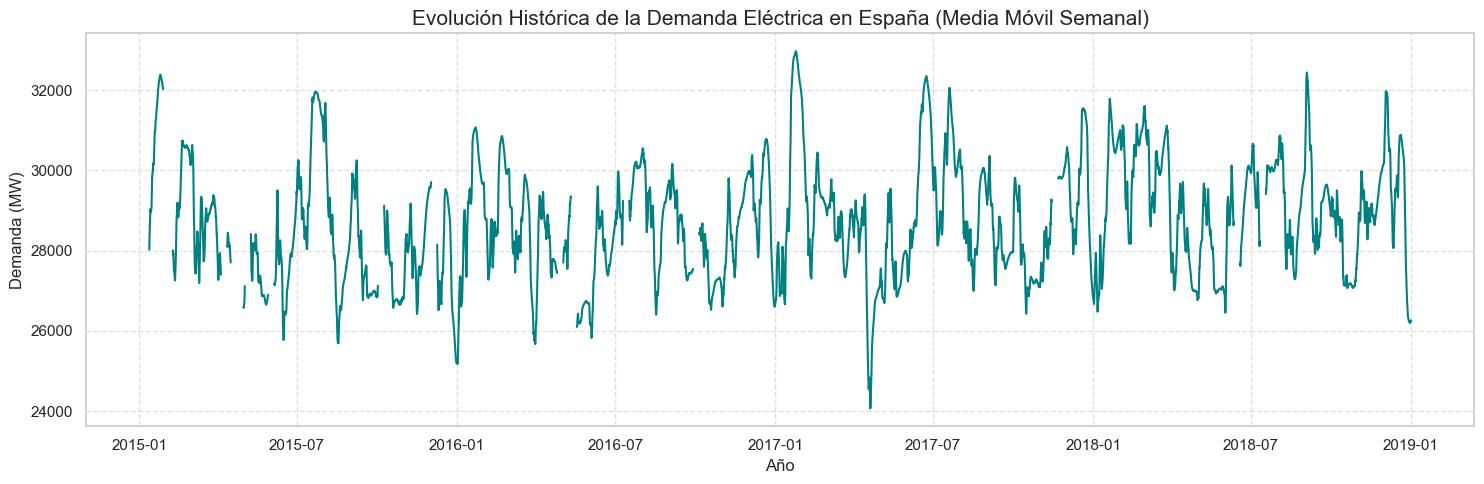

In [32]:
plt.figure(figsize=(15, 5))

df_suavizado = df.set_index('time_local')['total_load_actual'].rolling(window=168).mean()

plt.plot(df_suavizado.index, df_suavizado.values, color='teal', linewidth=1.5)
plt.title('Evolución Histórica de la Demanda Eléctrica en España (Media Móvil Semanal)', fontsize=15)
plt.xlabel('Año')
plt.ylabel('Demanda (MW)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Conclusiones del Análisis de Tendencia Histórica:**
* **Estabilidad:** A nivel interanual (de 2015 a 2018), la serie temporal es estable. No se observa una tendencia a la subida o a la bajada. El rango de consumo se mantiene constante a lo largo de los años.

### 4.4 Patrones Temporales y Climáticos

#### 4.4.1 Perfil Horario Promedio de la Demanda

Aquí se muestra el consumo eléctrico medio para cada una de las 24 horas del día. La línea representa la media histórica, y el área sombreada representa la desviación estándar.

Es la representación visual del "ritmo de vida" de la sociedad española. Nos permite identificar los valles de madrugada y los picos de máxima exigencia para la red eléctrica.

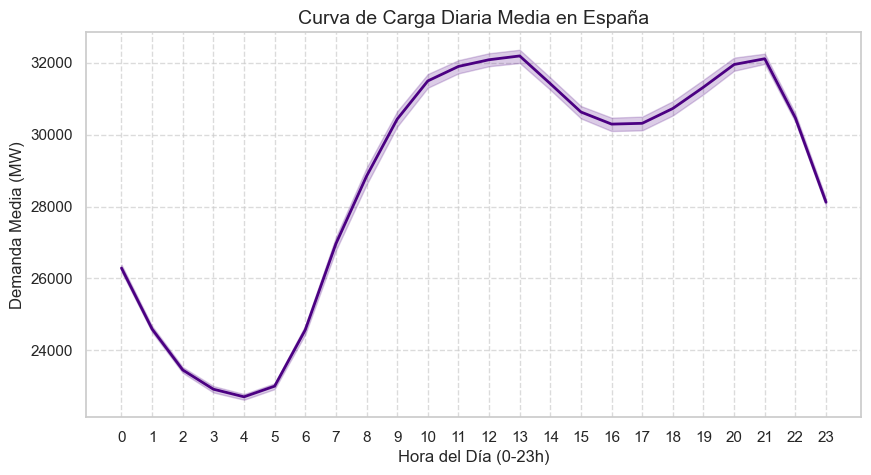

In [33]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=df, x='hour', y='total_load_actual', color='indigo', linewidth=2)

plt.title('Curva de Carga Diaria Media en España', fontsize=14)
plt.xlabel('Hora del Día (0-23h)')
plt.ylabel('Demanda Media (MW)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Conclusiones del Perfil Horario:**
* **Ciclo vital humano:** La demanda sigue perfectamente el ciclo laboral y vital. Se observa un valle profundo a las 04:00h de la madrugada (mínimo consumo). A partir de las 06:00h comienza una subida pronunciada por el inicio de la actividad industrial y comercial.
* **El pico de la tarde/noche:** Se observa un ligero descenso a mediodía (coincidiendo con las horas de mayor insolación y menor actividad laboral), pero el verdadero pico de tensión de la red ocurre alrededor de las **20:00h - 21:00h**. La gente vuelve a casa, enciende electrodomésticos y luces, coincidiendo con la caída de la generación solar. La variable `hora` será el predictor más importante del modelo.

#### 4.4.2 Estacionalidad Mensual de la Demanda

Aquí comparamos la demanda media según el mes del año, esto nos permite cuantificar el impacto térmico global que vimos en el scatterplot, pero ordenado temporalmente.

C:\Users\marti\AppData\Local\Temp\ipykernel_14668\381848107.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='month', y='total_load_actual', palette='Spectral', errorbar=None)


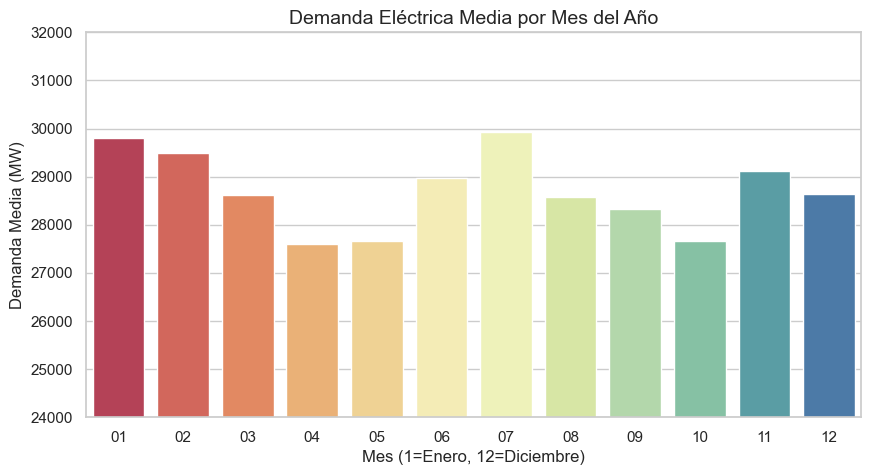

In [34]:
plt.figure(figsize=(10, 5))

# Agrupamos por mes y calculamos la media
sns.barplot(data=df, x='month', y='total_load_actual', palette='Spectral', errorbar=None)

plt.title('Demanda Eléctrica Media por Mes del Año', fontsize=14)
plt.xlabel('Mes (1=Enero, 12=Diciembre)')
plt.ylabel('Demanda Media (MW)')
# Establecemos el eje Y empezando en 20000 para magnificar las diferencias visuales
plt.ylim(24000, 32000)
plt.show()

**Conclusiones de la Estacionalidad Mensual:**
* **Los picos térmicos:** Enero y julio destacan claramente como los meses de mayor consumo medio, esto es debido al consumo de la calefacción o del AC.
* **El valle de primavera/otoño:** Abril y mayo, junto con noviembre, presentan los consumos medios más bajos debido a las temperaturas suaves que no requieren climatización activa en los hogares.

#### 4.4.3 Interacción Horaria y Estacional

Esta gráfica combina las dos ideas anteriores. Muestra la curva horaria a lo largo del día, pero separada por las estaciones con más consumo y es crucial para descubrir si el comportamiento de la gente (a qué hora se gasta más) cambia dependiendo de si es verano o invierno.

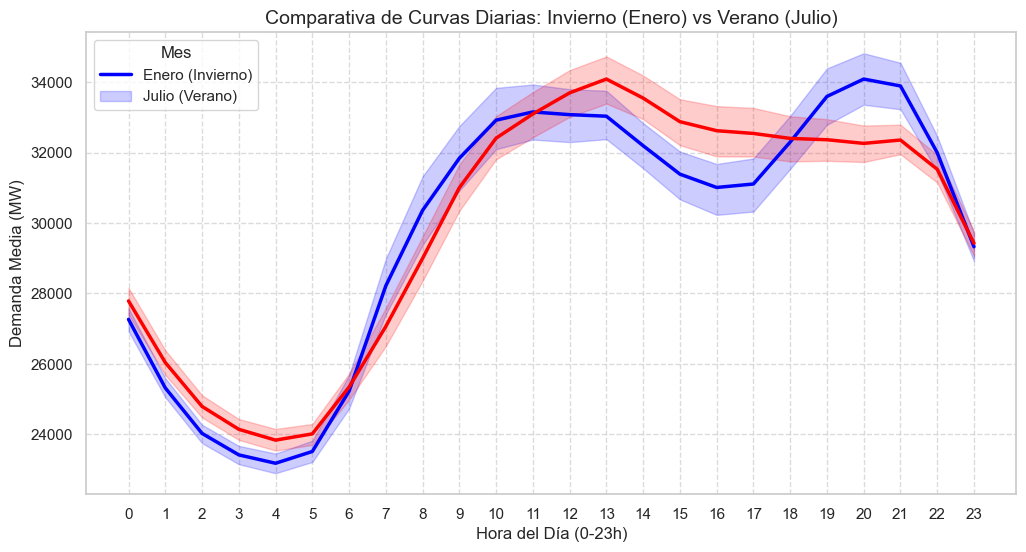

In [35]:

plt.figure(figsize=(12, 6))

# Convertimos month a número para la gráfica
df['month'] = df['month'].astype(int)

# Filtramos solo enero  y julio
df_estaciones = df[df['month'].isin([1, 7])]

sns.lineplot(data=df_estaciones, x='hour', y='total_load_actual', hue='month',
             palette=['blue', 'red'], linewidth=2.5)

plt.title('Comparativa de Curvas Diarias: Invierno (Enero) vs Verano (Julio)', fontsize=14)
plt.xlabel('Hora del Día (0-23h)')
plt.ylabel('Demanda Media (MW)')
plt.xticks(range(0, 24))

# leyenda
plt.legend(['Enero (Invierno)', 'Julio (Verano)'], title='Mes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Conclusiones de la Interacción:**
* **Desplazamiento del pico:** Esta es la gráfica más reveladora. Mientras que en invierno (línea azul) el pico absoluto de consumo nacional ocurre por la tarde/noche (20:00h, cuando anochece pronto y hace frío), en verano (línea roja) el comportamiento es distinto, llegando al punto más alto a las 13:00 y teniendo una suave pendiente descendiente hasta las 21:00.

### 4.5 Análisis de correlaciones

El último paso de nuestro análisis exploratorio es evaluar matemáticamente cómo se relacionan todas nuestras variables entre sí con una matríz de correlación.

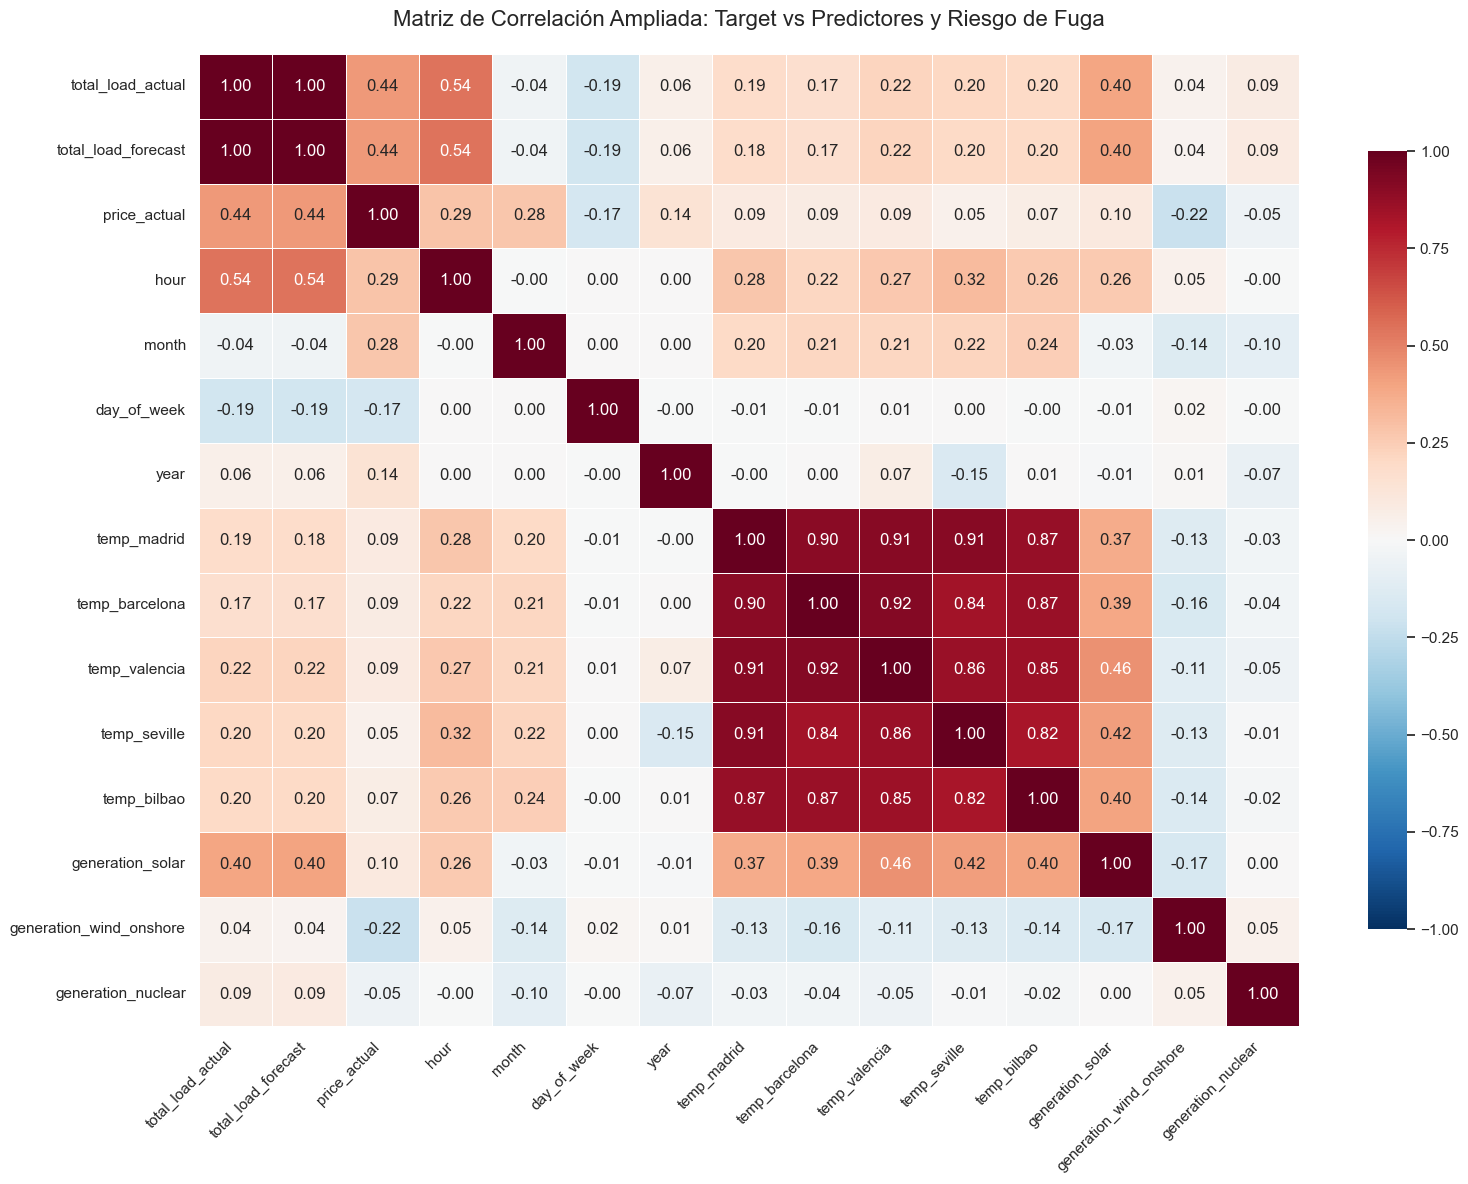

In [36]:
plt.figure(figsize=(16, 12))

cols_ampliadas = [
    'total_load_actual',
    'total_load_forecast',
    'price_actual',
    'hour', 'month', 'day_of_week', 'year',
    'temp_madrid', 'temp_barcelona', 'temp_valencia', 'temp_seville', 'temp_bilbao',
    'generation_solar', 'generation_wind_onshore', 'generation_nuclear'
]

matriz_corr_ampliada = df[cols_ampliadas].corr()

sns.heatmap(matriz_corr_ampliada, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f",
            linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación Ampliada: Target vs Predictores y Riesgo de Fuga', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusiones de la Matriz Ampliada y Decisiones Finales:**

* **1. Fuga de Información Crítica (`total_load_forecast`):** Vemos que la correlación entre la demanda real y la previsión  es casi perfecta. Sin embargo, **debemos eliminar esta variable**. Nuestro objetivo es construir un modelo que *haga* esa previsión. Si le damos al algoritmo las respuestas hechas por el operador de la red, el modelo no estará aprendiendo a predecir, solo estará copiando.
* **2. Variables Consecuencia (`price_actual` y `generation`):** El precio de la luz tiene una correlación moderada/alta con la demanda. Sin embargo, en el mercado eléctrico, **el precio es una consecuencia de la demanda**, no su causa (ley de oferta y demanda). Además, si queremos predecir la demanda de "mañana", hoy no conocemos con exactitud ni el precio real de mañana ni los MW exactos que generará la energía nuclear o solar mañana. Incluir estas variables engañaría al modelo haciéndole parecer artificialmente preciso. **Quedan descartadas.**
* **3. La Trampa de las temperaturas:** La correlación lineal directa con las temperaturas parece cercana a 0. Pero como ya hemos visto en otros diagramas como el de dispersión o el del consumo horario si existe una relación entre ambas.
* **4. Temperaturas redundantes:** Al observar las temperaturas entre sí, detectamos colinealidad extrema (ej. Barcelona y Valencia tienen una correlación >0.90). Para evitar el sobreajuste (overfitting) y simplificar el modelo, **podriamos ver de prescindir de Valencia y Bilbao**, manteniendo a Madrid (centro), Sevilla (sur caluroso) y Barcelona (costa mediterránea) como pilares climáticos.

**Conclusión Final de Selección:** El modelo predictivo se alimentará exclusivamente de las variables que sí conocemos antes de que ocurra el evento: **El calendario (`hour`, `day_of_week`, `month`) y las previsiones meteorológicas (`temp_madrid`, `temp_barcelona`, `temp_seville`).**

## 5. Preparación del Conjunto de Datos (Feature Engineering)

En esta fase transformaremos el dataset original en la matriz matemática final que alimentará nuestro modelo predictivo, cumpliendo con los requisitos de limpieza, adecuación e ingeniería de características.




### 5.1. Selección Final y Prevención de Data Leakage (Fuga de Información)

**Justificación de las variables eliminadas:**
Basándonos en los resultados de nuestro EDA (Matriz de Correlación Ampliada), aplicamos un filtrado estricto para garantizar que nuestro modelo sea matemáticamente válido y aplicable en un entorno operativo real. Se descartan las siguientes familias de variables:

* **1. Variables de Precios y Previsiones (`price_actual`, `total_load_forecast`):** Se eliminan por riesgo crítico de **Fuga de Información**. El objetivo de este modelo es predecir la demanda futura. En la vida real, en el momento de ejecutar la predicción, no disponemos del precio real de la luz de mañana. Entrenar al algoritmo dándole las respuestas por adelantado invalidaría el modelo.
* **2. Variables de Generación Eléctrica (`generation_solar`, `generation_wind`, etc.):** Se excluyen por dos motivos. Primero, de nuevo, por *Fuga de Datos* (no sabemos a priori cuántos MW generará el viento mañana a las 15:00h). Segundo, por un principio de **Causalidad**: la generación eléctrica es una *consecuencia* de la demanda. El modelo debe aprender los verdaderos móviles del consumo como el reloj social y el clima.
* **3. Temperaturas Redundantes (`temp_valencia`, `temp_bilbao`):** Se eliminan por **Multicolinealidad**. Como vimos en el Heatmap, están altamente correlacionadas con otras ciudades. Para evitar la "maldición de la dimensionalidad" y el sobreajuste (overfitting), conservamos únicamente Madrid (clima central/continental), Barcelona (costa mediterránea) y Sevilla (extremo sur caluroso) como sensores climáticos de la Península.

In [37]:
# Definimos la lista estricta de columnas
columnas_finales = [
    'time_local',
    'total_load_actual',
    'hour', 'month', 'day_of_week',
    'temp_madrid', 'temp_barcelona', 'temp_seville'
]

# Filtramos el dataframe original
df_model = df[columnas_finales].copy()

#Ordenamos cronológicamente para evitar aprender del futuro
df_model = df_model.sort_values('time_local').reset_index(drop=True)

print(f"Dimensiones tras la selección: {df_model.shape}")

Dimensiones tras la selección: (35064, 8)


### 5.2: Inspección de Calidad Final

In [38]:
print("--- TIPOS DE DATOS ---")
print(df_model.dtypes)
print("\n--- RECUENTO DE VALORES NULOS ---")
print(df_model.isnull().sum())

--- TIPOS DE DATOS ---
time_local           datetime64[ns, Europe/Madrid]
total_load_actual                          float64
hour                                         int32
month                                        int32
day_of_week                                  int32
temp_madrid                                float64
temp_barcelona                             float64
temp_seville                               float64
dtype: object

--- RECUENTO DE VALORES NULOS ---
time_local            0
total_load_actual    36
hour                  0
month                 0
day_of_week           0
temp_madrid           0
temp_barcelona        0
temp_seville          0
dtype: int64


In [39]:
display(df_model.head(3))

,time_local,total_load_actual,hour,month,day_of_week,temp_madrid,temp_barcelona,temp_seville
0,2015-01-01 00:00:00+01:00,25385.0,0,1,3,267.325,281.625,273.375
1,2015-01-01 01:00:00+01:00,24382.0,1,1,3,267.325,281.625,273.375
2,2015-01-01 02:00:00+01:00,22734.0,2,1,3,266.186,281.286,274.086


#### 5.2.1. Manejo de Valores Faltantes

El análisis de calidad ha revelado la existencia de **36 valores nulos** en nuestra variable objetivo `total_load_actual`. Dado que representan apenas un 0.1% del volumen total (35.064 horas) y se trata de una serie temporal continua, la técnica más robusta y matemáticamente correcta es la **Interpolación Lineal**.
Este método rellena el hueco trazando una línea recta entre el valor de la hora anterior y el de la hora siguiente, preservando la continuidad de la curva de demanda sin alterar la media global ni introducir sesgos artificiales.

In [40]:
# Aplicamos interpolación linea
df_model['total_load_actual'] = df_model['total_load_actual'].interpolate(method='linear')

# Verificación
print("--- RECUENTO DE NULOS TRAS LA IMPUTACIÓN ---")
print(df_model.isnull().sum())

--- RECUENTO DE NULOS TRAS LA IMPUTACIÓN ---
time_local           0
total_load_actual    0
hour                 0
month                0
day_of_week          0
temp_madrid          0
temp_barcelona       0
temp_seville         0
dtype: int64


### 5.3. Ingeniería de Características: Variables Temporales

Para dotar al modelo de contexto histórico, crearemos variables basadas en el pasado inmediato.

* **Lags:** Consumo de hace exactamente 24 horas y hace 168 horas (1 semana).
* **Rolling:** Consumo medio de las últimas 24 horas.

In [41]:
#Lags
df_model['lag_24h'] = df_model['total_load_actual'].shift(24)
df_model['lag_168h'] = df_model['total_load_actual'].shift(168)

#Rolling
df_model['rolling_mean_24h'] = df_model['total_load_actual'].shift(1).rolling(window=24).mean()

#Borramos los valores nulos que se generan por falta de historial
df_model = df_model.dropna().reset_index(drop=True)

print(f"Dimensiones tras añadir memoria temporal y limpiar NaNs iniciales: {df_model.shape}")

Dimensiones tras añadir memoria temporal y limpiar NaNs iniciales: (34896, 11)


### 5.4. División del Dataset (Train / Test Split Temporal)

Dividiremos los datos en Entrenamiento (80%) y Prueba (20%).
Al tratarse de una serie temporal, **no se barajan los datos** (`shuffle=False`). Se respeta el orden cronológico absoluto para entrenar al modelo con el pasado y evaluarlo prediciendo el futuro.

In [42]:
# Calculamos el índice exacto de corte (80%)
indice_corte = int(len(df_model) * 0.8)

# Partición cronológica
train_df = df_model.iloc[:indice_corte].copy()
test_df = df_model.iloc[indice_corte:].copy()

# Separamos Predictores (X) del Objetivo (y)
features = ['hour', 'month', 'day_of_week', 'temp_madrid', 'temp_barcelona', 'temp_seville',
            'lag_24h', 'lag_168h', 'rolling_mean_24h']
target = 'total_load_actual'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(f"Train: {X_train.shape[0]} horas. Desde {train_df['time_local'].min()} hasta {train_df['time_local'].max()}")
print(f"Test:  {X_test.shape[0]} horas. Desde {test_df['time_local'].min()} hasta {test_df['time_local'].max()}")

Train: 27916 horas. Desde 2015-01-08 00:00:00+01:00 hasta 2018-03-16 03:00:00+01:00
Test:  6980 horas. Desde 2018-03-16 04:00:00+01:00 hasta 2018-12-31 23:00:00+01:00


### 5.5. Escalado de Características (Standardization)

Nuestras variables manejan escalas muy distintas (Kelvin, MW, horas). Para ayudar a la convergencia matemática de los modelos, estandarizamos las variables (media 0, varianza 1).

El motivo fundamental por ela estandarización se aplica después de haber dividido el dataset en conjuntos de Entrenamiento (Train) y Prueba (Test) es para prevenir la Fuga de Información (Data Leakage).

Algoritmos de escalado como StandardScaler transforman los datos restando la media y dividiendo por la desviación estándar de cada variable. Si aplicáramos esta transformación al dataset completo antes de realizar la partición temporal, estaríamos utilizando los datos del conjunto de Prueba (el "futuro") para calcular esa media y desviación estándar globales.

In [43]:
# Inicializamos
scaler = StandardScaler()

# Fit solo en Train, y transform en ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconvertimos a DataFrame para mantener los nombres de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

display(X_train_scaled.head(3))

,hour,month,day_of_week,temp_madrid,temp_barcelona,temp_seville,lag_24h,lag_168h,rolling_mean_24h
0,-1.660985,-1.490825,-0.000072,-2.114699,-0.733176,-1.988330,0.402000,-0.711810,1.320143
1,-1.516534,-1.490825,-0.000072,-2.151060,-0.763140,-2.019413,-0.041278,-0.930393,1.260347
2,-1.372082,-1.490825,-0.000072,-2.187421,-0.793105,-2.050495,-0.359027,-1.289540,1.206834


### Guardado de datos

In [45]:
# Guardamos df_model que es donde has hecho toda la limpieza
df_model.to_csv(os.path.join(PROCESSED_DIR, "datos_limpios_hito01.csv"), index=False)

# Guardamos el escalador
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler_maestro.pkl"))

print("Hito 1: Datos y escalador guardados correctamente.")

Hito 1: Datos y escalador guardados correctamente.
